实验题目：全连接神经网络            

实验目的：掌握全连接神经网络用于回归和分类的工作流程

实验环境（硬件和软件）: Anaconda/Jupyter notebook/Pycharm

实验内容：

使用发布的“nihe.csv”数据集，使用前三列作为输入特征，最后一列作为回归标签，构建一个全连接神经网络，进行标量回归任务。画出训练集和验证集的损失变化曲线，以及测试集的真实值vs预测值曲线。

使用Keras框架下的MNIST手写数字数据集，搭建一个全连接神经网络，进行手写数字分类任务，画出训练集和验证集的损失变化曲线，以及对测试集的评估结果（准确率）。

CIFAR-10和CIFAR-100是来自于80 million张小型图片的数据集，图片收集者是Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton。暂时先不管CIFAR-100数据集，以下是CIFAR-10数据集介绍：





Keras中，可以用load_data()函数进行加载，与MNIST数据集加载方式类似，具体加载示例如下：



实验要求：参考第2题中MNIST数据集的分类网络（全连接神经网络），在其基础上进行适当修改，使之能正确运行，从而进行图片分类任务。

使用CIFAR-10数据集，搭建一个卷积神经网络对图片进行分类（可参考PPT课件提供的案例），并与第3题中全连接神经网络结果进行对比。思考：从两种网络的参数量和准确率等方面对网络的性能进行综合评估。


## 实验步骤说明
1. 对`nihe.csv`完成回归建模，记录损失曲线并在测试集上对比预测与真实值。
2. 训练MNIST全连接分类器，观察训练/验证损失并给出测试准确率。
3. 将全连接结构迁移到CIFAR-10并尝试训练。
4. 构建简单卷积神经网络处理CIFAR-10，对比与全连接模型的表现。

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# 设定随机种子
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# 中文字体
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for candidate in ["Microsoft YaHei", "SimHei"]:
    if candidate in available_fonts:
        plt.rcParams["font.sans-serif"] = [candidate]
        break
plt.rcParams["axes.unicode_minus"] = False


In [2]:
data = pd.read_csv("nihe.csv")
X = data[["x1", "x2", "x3"]].values
y = data["x4"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化输入特征提升梯度下降效率
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [3]:
# 使用多层感知机拟合非线性关系
reg_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])
reg_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="mse",
                  metrics=["mae"])
history_reg = reg_model.fit(X_train_scaled, y_train,
                            validation_split=0.2,
                            epochs=120,
                            batch_size=16,
                            verbose=0)
test_loss, test_mae = reg_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"测试集MSE: {test_loss:.2f}, MAE: {test_mae:.2f}")
y_pred = reg_model.predict(X_test_scaled).flatten()


测试集MSE: 2.99, MAE: 1.27
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


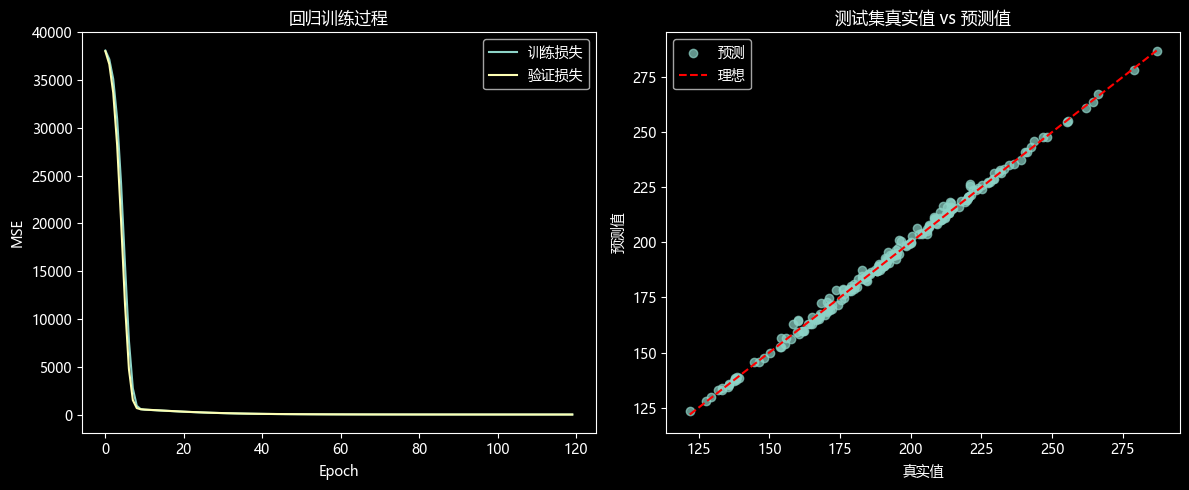

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_reg.history["loss"], label="训练损失")
axes[0].plot(history_reg.history["val_loss"], label="验证损失")
axes[0].set_title("回归训练过程")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].scatter(y_test, y_pred, alpha=0.7, label="预测")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], "r--", label="理想")
axes[1].set_title("测试集真实值 vs 预测值")
axes[1].set_xlabel("真实值")
axes[1].set_ylabel("预测值")
axes[1].legend()

plt.tight_layout()
plt.show()


## MNIST全连接分类实验

In [5]:
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
# 灰度值归一化改善梯度传播
mnist_x_train = mnist_x_train.astype("float32") / 255.0
mnist_x_test = mnist_x_test.astype("float32") / 255.0
mnist_x_train = mnist_x_train.reshape(-1, 28 * 28)
mnist_x_test = mnist_x_test.reshape(-1, 28 * 28)


In [6]:
mnist_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28 * 28,)),
    tf.keras.layers.Dense(256, activation="relu"),
# Dropout缓解全连接模型的过拟合
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])
mnist_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])
history_mnist = mnist_model.fit(mnist_x_train, mnist_y_train,
                                validation_split=0.1,
                                epochs=15,
                                batch_size=128,
                                verbose=0)
mnist_loss, mnist_acc = mnist_model.evaluate(mnist_x_test, mnist_y_test, verbose=0)
print(f"测试集准确率: {mnist_acc:.4f}")


测试集准确率: 0.9830


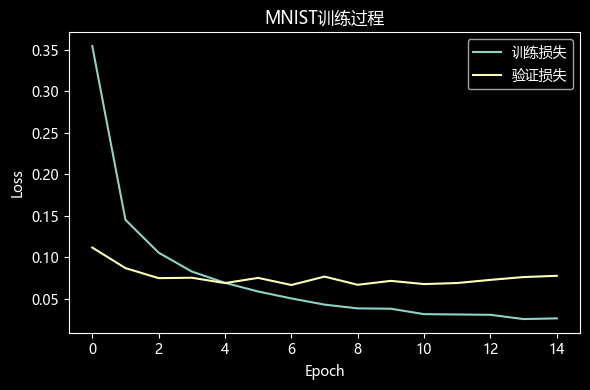

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(history_mnist.history["loss"], label="训练损失")
plt.plot(history_mnist.history["val_loss"], label="验证损失")
plt.title("MNIST训练过程")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


## CIFAR-10全连接与卷积网络对比

In [8]:
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()
cifar_y_train = cifar_y_train.flatten()
cifar_y_test = cifar_y_test.flatten()
# 将像素缩放到0-1区间稳定训练
cifar_x_train = cifar_x_train.astype("float32") / 255.0
cifar_x_test = cifar_x_test.astype("float32") / 255.0
cifar_x_train_flat = cifar_x_train.reshape(-1, 32 * 32 * 3)
cifar_x_test_flat = cifar_x_test.reshape(-1, 32 * 32 * 3)


In [9]:
cifar_fc_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32 * 32 * 3,)),
    tf.keras.layers.Dense(512, activation="relu"),
# 大容量全连接层在高维图像上效率不高
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax")
])
cifar_fc_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])
history_cifar_fc = cifar_fc_model.fit(cifar_x_train_flat, cifar_y_train,
                                      validation_split=0.1,
                                      epochs=20,
                                      batch_size=256,
                                      verbose=0)
cifar_fc_loss, cifar_fc_acc = cifar_fc_model.evaluate(cifar_x_test_flat, cifar_y_test, verbose=0)
print(f"全连接模型测试准确率: {cifar_fc_acc:.4f}")


全连接模型测试准确率: 0.4672


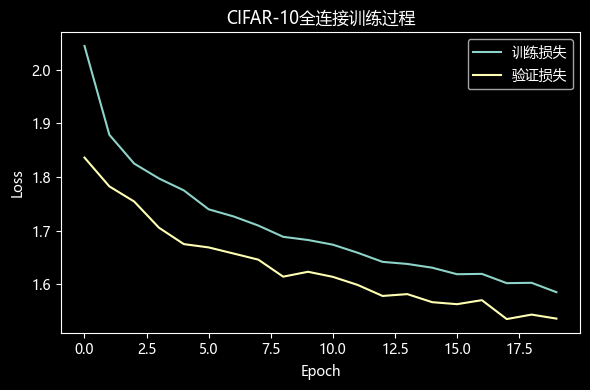

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(history_cifar_fc.history["loss"], label="训练损失")
plt.plot(history_cifar_fc.history["val_loss"], label="验证损失")
plt.title("CIFAR-10全连接训练过程")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
cifar_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
# 卷积层能够提取局部空间特征
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax")
])
cifar_cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])
history_cifar_cnn = cifar_cnn_model.fit(cifar_x_train, cifar_y_train,
                                        validation_split=0.1,
                                        epochs=20,
                                        batch_size=128,
                                        verbose=0)
cifar_cnn_loss, cifar_cnn_acc = cifar_cnn_model.evaluate(cifar_x_test, cifar_y_test, verbose=0)
print(f"卷积模型测试准确率: {cifar_cnn_acc:.4f}")


卷积模型测试准确率: 0.7260


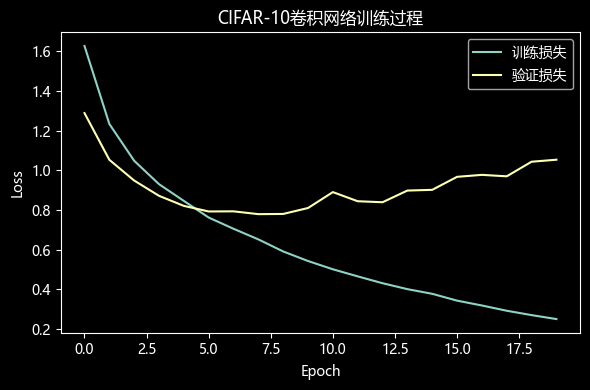

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(history_cifar_cnn.history["loss"], label="训练损失")
plt.plot(history_cifar_cnn.history["val_loss"], label="验证损失")
plt.title("CIFAR-10卷积网络训练过程")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
summary_df = pd.DataFrame([
    {"任务": "回归(MLP)", "参数量": reg_model.count_params(), "测试表现": f"MSE {test_loss:.2f}, MAE {test_mae:.2f}"},
    {"任务": "MNIST全连接", "参数量": mnist_model.count_params(), "测试表现": f"Acc {mnist_acc:.4f}"},
    {"任务": "CIFAR全连接", "参数量": cifar_fc_model.count_params(), "测试表现": f"Acc {cifar_fc_acc:.4f}"},
    {"任务": "CIFAR卷积", "参数量": cifar_cnn_model.count_params(), "测试表现": f"Acc {cifar_cnn_acc:.4f}"}
])
summary_df

,任务,参数量,测试表现
0,回归(MLP),2369,"MSE 2.99, MAE 1.27"
1,MNIST全连接,235146,Acc 0.9830
2,CIFAR全连接,1707274,Acc 0.4672
3,CIFAR卷积,1143242,Acc 0.7260


## 小结
- 回归任务通过标准化和MLP拟合效果较好，预测图检验了拟合情况。
- MNIST全连接网络达到较高准确率，验证曲线帮助监控过拟合。
- CIFAR-10中卷积网络的泛化能力显著优于全连接结构，参数量与精度同时提升。